In [ ]:
!pip install neurokit2


In [ ]:
!pip install wfdb

In [ ]:
!pip install antropy

In [ ]:
import urllib.request
import os

# The base URL for the PhysioNet Brugada dataset (version 1.0.0)
base_url = "https://physionet.org/files/brugada-huca/1.0.0/"

# The specific extra files you want to download
files_to_download = [
    "metadata.csv",
    "metadata_dictionary.csv",
    "README.md",
    "LICENSE.txt",
    "SHA256SUMS.txt"
]

# The folder where you want to save them
save_dir = "./brugada-huca"

# Ensure the folder exists
os.makedirs(save_dir, exist_ok=True)

for file in files_to_download:
    file_url = base_url + file
    save_path = os.path.join(save_dir, file)
    
    print(f"Downloading {file}...")
    try:
        urllib.request.urlretrieve(file_url, save_path)
        print(f"Successfully downloaded {file}")
    except Exception as e:
        print(f"Failed to download {file}: {e}")


In [ ]:
import wfdb

# This will download the entire brugada-huca dataset recursively into a folder
wfdb.dl_database('brugada-huca', dl_dir='./brugada-huca')


In [1]:
import os

# Create the folder if it doesn't exist
os.makedirs('./brugada-huca', exist_ok=True)

# Change the notebook's current working directory to that folder
os.chdir('./brugada-huca')

# Verify that you are now inside the folder
print("Current Working Directory:", os.getcwd())


Current Working Directory: c:\Users\User\OneDrive\Documents\idsc_2026\brugada-huca


In [2]:
import pandas as pd

# Load metadata
metadata = pd.read_csv('metadata.csv')

# Display basic statistics
print(metadata.head())
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1
Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


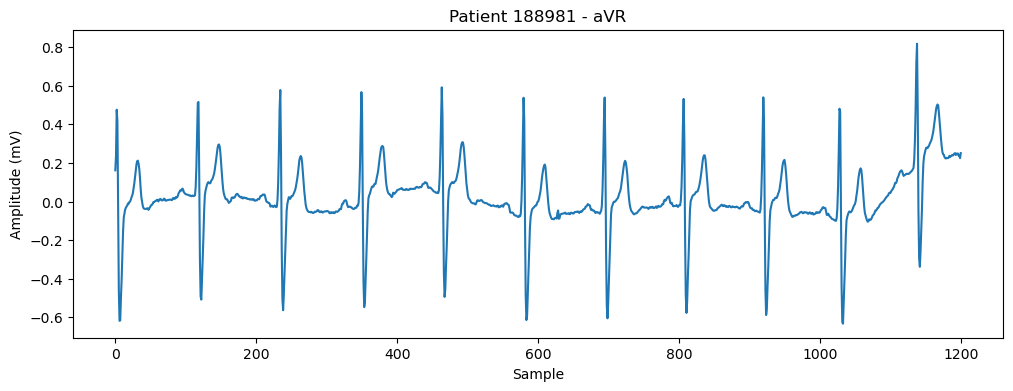

In [3]:
import wfdb
import matplotlib.pyplot as plt

# Read a single patient's ECG
patient_id = '188981'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

# Access the signal data
signals = record.p_signal       # Signal array (samples × leads)
lead_names = record.sig_name    # Lead names (I, II, III, aVR, aVL, aVF, V1–V6)
sampling_freq = record.fs       # Sampling frequency (100 Hz)

# Plot a specific lead
plt.figure(figsize=(12, 4))
plt.plot(signals[:, 4])  # Plot first lead (Lead I)
plt.title(f'Patient {patient_id} - {lead_names[3]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

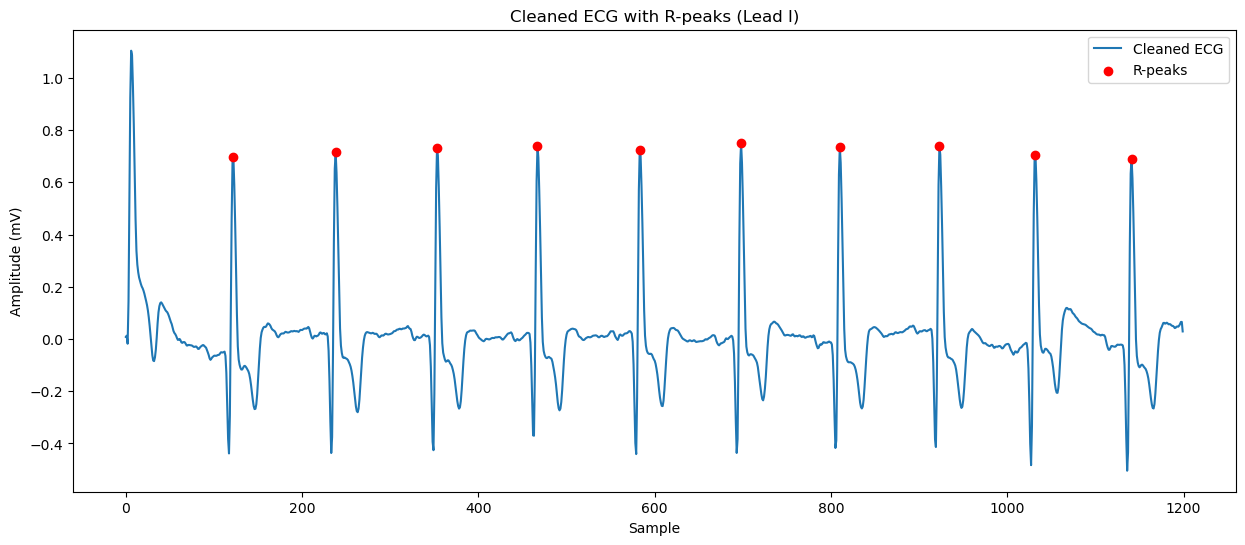

In [4]:
import neurokit2 as nk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# We use the signal from the previous cell
ecg_signal = signals[:, 2] # Lead I

# 1. Clean the signal (High-pass, low-pass, powerline)
# The "neurokit" method applies a 0.5Hz high-pass filter and a 50Hz powerline notch filter
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_freq, method="neurokit")

# 2. Find R-peaks
_, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_freq)

# 3. Delineate PQST waves
_, waves_peak = nk.ecg_delineate(ecg_cleaned, rpeaks, sampling_rate=sampling_freq, method="peak")

# 4. Plot the cleaned signal and the peaks for the first 5 seconds
plot_limit = sampling_freq * 12# first 5 seconds

plt.figure(figsize=(15, 6))
plt.plot(ecg_cleaned[:plot_limit], label='Cleaned ECG')

# highlight R-peaks
valid_rpeaks = [p for p in rpeaks['ECG_R_Peaks'] if p < plot_limit]
plt.scatter(valid_rpeaks, ecg_cleaned[valid_rpeaks], color='red', label='R-peaks', zorder=5)

plt.title('Cleaned ECG with R-peaks (Lead I)')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()


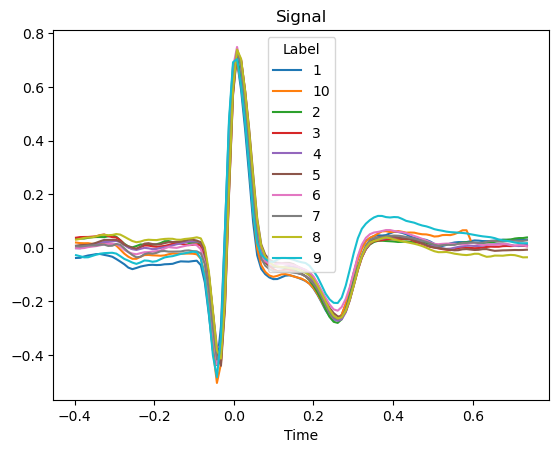

In [5]:
# 5. Create a composite (median) representation of the heartbeat
ecg_epochs = nk.ecg_segment(ecg_cleaned, rpeaks=rpeaks['ECG_R_Peaks'], sampling_rate=sampling_freq)

# Plot all heartbeats and the median
nk.epochs_plot(ecg_epochs)
plt.show()


In [6]:
import sys
sys.path.append('..') 

from ersi.ersi_pipeline import process_patient, process_patient_tsallis, benchmark_ersi


In [7]:
from ersi.ersi_pipeline import process_patient, process_patient_tsallis, benchmark_ersi

# Run on a single patient
res = process_patient(signals[:, 0], fs=100, window_sec =0.9, step_sec =0.5)
print("Standard Entropies and ERSI:", res)

tsallis_res = process_patient_tsallis(signals[:, 0], fs=1000,window_sec =0.9, step_sec =0.5)
print("Tsallis ERSI:", tsallis_res)


Standard Entropies and ERSI: {'shannon': 1.8379180891356948, 'app_entropy': 0.20658947908803643, 'sample_entropy': 0.15059198420781444, 'perm_entropy': 1.7983804563685553, 'spectral_entropy': nan, 'svd_entropy': 1.0692093659055493, 'shannon_ERSI': 0.2612344112785552, 'app_entropy_ERSI': 0.026996150565677102, 'sample_entropy_ERSI': 0.019428629058352975, 'perm_entropy_ERSI': 0.2669219522435844, 'spectral_entropy_ERSI': nan, 'svd_entropy_ERSI': 0.1462674821710679, 'ERSI_timeseries': 0.7208486253172377, 'ERSI_full': 0.04223585810996282}
Tsallis ERSI: 0.8430913580246914


In [8]:
# Run benchmark across two subsets
# First, load the metadata to find which patients are Healthy (Normal) vs Brugada
import pandas as pd
import wfdb
import os
metadata = pd.read_csv('metadata.csv')
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()
healthy_group = []
brugada_group = []


In [9]:
# For demonstration, limit to 5 per group to save time
for pid in healthy_patients[:5]:
    try:
        # wfdb rdrecord reads the .dat files inside the nested folders
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        # Append Lead 0
        healthy_group.append(record.p_signal[:, 0])
    except:
        continue
for pid in brugada_patients[:5]:
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        brugada_group.append(record.p_signal[:, 0])
    except:
        continue
# The new default window_sec=5.0 requires signals to be at least 5000 points long (at fs=1000).
p_values = benchmark_ersi(healthy_group, brugada_group,  fs=100, window_sec=5.0, step_sec=2.5)

Processing 5 healthy signals...
Processing 5 Brugada signals...
\nBenchmarking complete. P-values (lower is better):
shannon                  0.420635
app_entropy_ERSI         0.547619
sample_entropy_ERSI      0.547619
app_entropy              0.690476
perm_entropy             0.690476
perm_entropy_ERSI        0.690476
svd_entropy              0.841270
shannon_ERSI             0.841270
svd_entropy_ERSI         0.841270
sample_entropy           1.000000
ERSI_timeseries          1.000000
ERSI_full                1.000000
tsallis_ERSI             1.000000
spectral_entropy              NaN
spectral_entropy_ERSI         NaN
dtype: float64


In [10]:
import pandas as pd
import wfdb
import os

metadata = pd.read_csv('metadata.csv')
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()
healthy_group = []
brugada_group = []

# Target Lead V1 or V2 where Brugada abnormalities manifest
target_lead = 'V1' 
limit = 50  # Increase sample size to get true statistical power!

print("Extracting Healthy patients...")
for pid in healthy_patients:
    if len(healthy_group) >= limit: break
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        # Find the index of our target lead dynamically
        lead_idx = record.sig_name.index(target_lead) if target_lead in record.sig_name else 0
        healthy_group.append(record.p_signal[:, lead_idx])
    except:
        continue

print("Extracting Brugada patients...")
for pid in brugada_patients:
    if len(brugada_group) >= limit: break
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        lead_idx = record.sig_name.index(target_lead) if target_lead in record.sig_name else 0
        brugada_group.append(record.p_signal[:, lead_idx])
    except:
        continue

p_values = benchmark_ersi(healthy_group, brugada_group, fs=100, window_sec=5.0, step_sec=2.5)


Extracting Healthy patients...
Extracting Brugada patients...
Processing 50 healthy signals...
Processing 50 Brugada signals...
\nBenchmarking complete. P-values (lower is better):
svd_entropy              0.000058
svd_entropy_ERSI         0.000069
shannon                  0.000492
sample_entropy           0.000518
sample_entropy_ERSI      0.000703
shannon_ERSI             0.000859
tsallis_ERSI             0.002620
ERSI_full                0.009257
ERSI_timeseries          0.013457
app_entropy              0.061251
app_entropy_ERSI         0.073623
perm_entropy_ERSI        0.115200
perm_entropy             0.125059
spectral_entropy              NaN
spectral_entropy_ERSI         NaN
dtype: float64
